# **Libraries**

In [ ]:
import os
from google.colab import files
from fastai.vision.all import *
from pathlib import Path
import timm

# **Auxiliar Functions**

In [ ]:
def show_results(dls,learner,mode):
  """Displays confusion matrix and accuracy for a given mode (Train, Valid, Test).

  Args:
    dls: The DataLoaders object containing train, valid, and test data.
    learner: The Learner object with the trained model.
    mode: A string indicating the dataset to evaluate ('Train', 'Valid', or 'Test').
  """

  if mode=='Train':
    dl=dls.train
  elif mode=='Validation':
    dl=dls.valid
  elif mode=='Test':
    test_path = path/'test'
    test_files = [fn for fn in sorted(test_path.glob('**/*')) if fn.is_file()]
    dl = learner.dls.test_dl(test_files,with_labels=True, device='cuda') # Test set also normalized the same way

  # Confusion Matrix
  interp = ClassificationInterpretation.from_learner(learner, 1, dl)
  cm = interp.confusion_matrix()
  print(f'Number of {mode} Examples:', np.sum(cm))
  interp.plot_confusion_matrix(figsize=(12, 12),title=f'Confusion Matrix for the {mode} Set')

  # Accuracy
  acc= np.sum(np.diagonal(cm))/np.sum(cm)*100
  print(f'{mode} Accuracy: {acc}%')

# **Dataset Preparing**

## **Download**

In [ ]:
# --- 1. CONFIGURACIÓN DE KAGGLE API ---
kaggle_json_path = os.path.expanduser("~/.config/kaggle/kaggle.json")
token_setup_successful = False

# Verificar si kaggle.json ya existe
if not os.path.exists(kaggle_json_path):
    print("⬇️ Token no encontrado. Sube tu archivo kaggle.json ⬇️")
    uploaded = files.upload() # files.upload() returns a dict of uploaded files

    if 'kaggle.json' in uploaded:
        # Crear la carpeta oculta si no existe
        !mkdir -p ~/.config/kaggle
        # Mover el archivo json ahí dentro
        !mv kaggle.json ~/.config/kaggle/ # Usamos mv para evitar dejar una copia en /content
        # Dar los permisos de seguridad (lectura/escritura solo para ti)
        !chmod 600 ~/.config/kaggle/kaggle.json
        print("✅ Configuración completada: Fichero movido a ~/.config/kaggle/")
        token_setup_successful = True

        !pip install kaggle --quiet
        !kaggle --version
        from kaggle.api.kaggle_api_extended import KaggleApi
    else:
        print("❌ No se subió el archivo kaggle.json. Asegúrate de subirlo para continuar.")
else:
    print("✅ kaggle.json ya existe en ~/.config/kaggle/. Saltando la subida.")
    token_setup_successful = True

# Proceder con la autenticación y descarga solo si el token se configuró correctamente
if token_setup_successful:
    try:
        # Inicializamos la API (esto debe hacerse siempre para asegurar que la API está autenticada)
        # La API buscará automáticamente el archivo kaggle.json en ~/.config/kaggle/
        api = KaggleApi()
        api.authenticate()
        print("✅ Autenticación con Kaggle API exitosa.")

        # --- 2. DESCARGA DEL DATASET ---
        dataset_path = '/content/dataset'

        # Verificar si el dataset ya está descargado y descomprimido
        # Comprobamos si la carpeta existe y si contiene archivos
        if not os.path.exists(dataset_path) or not os.listdir(dataset_path):
            print("⏳ Descargando dataset en /content/dataset...")
            api.dataset_download_files(
                'wanderdust/skin-lesion-analysis-toward-melanoma-detection',
                path=dataset_path,
                unzip=True,
                quiet=False
            )
            print("✅ ¡Descarga finalizada!")

            # Borrar el archivo zip descargado para ahorrar espacio
            print("🧹 Limpiando archivos zip...")
            for file in os.listdir(dataset_path):
                if file.endswith(".zip"):
                    os.remove(os.path.join(dataset_path, file))
            print("✅ Archivo zip eliminado correctamente.")
        else:
            print("✅ Dataset ya descargado y descomprimido en /content/dataset/. Saltando la descarga.")
    except Exception as e:
        print(f"❌ Error durante la autenticación o descarga del dataset: {e}")
else:
    print("⚠️ No se puede proceder con la autenticación o descarga del dataset sin un archivo kaggle.json válido.")

✅ kaggle.json ya existe en ~/.config/kaggle/. Saltando la subida.
✅ Autenticación con Kaggle API exitosa.
✅ Dataset ya descargado y descomprimido en /content/dataset/. Saltando la descarga.


## **Creation of the Datablock**

In [ ]:
!ls -lha
!ls /content/dataset/skin-lesions/

total 20K
drwxr-xr-x 1 root root 4.0K Dec  1 13:14 .
drwxr-xr-x 1 root root 4.0K Dec  1 12:54 ..
drwxr-xr-x 4 root root 4.0K Nov 20 14:30 .config
drwxr-xr-x 3 root root 4.0K Dec  1 13:16 dataset
drwxr-xr-x 1 root root 4.0K Nov 20 14:30 sample_data
test  train  valid


In [ ]:
path = Path("/content/dataset/skin-lesions")
train_path = path/'train'
valid_path = path/'valid'
test_path  = path/'test'

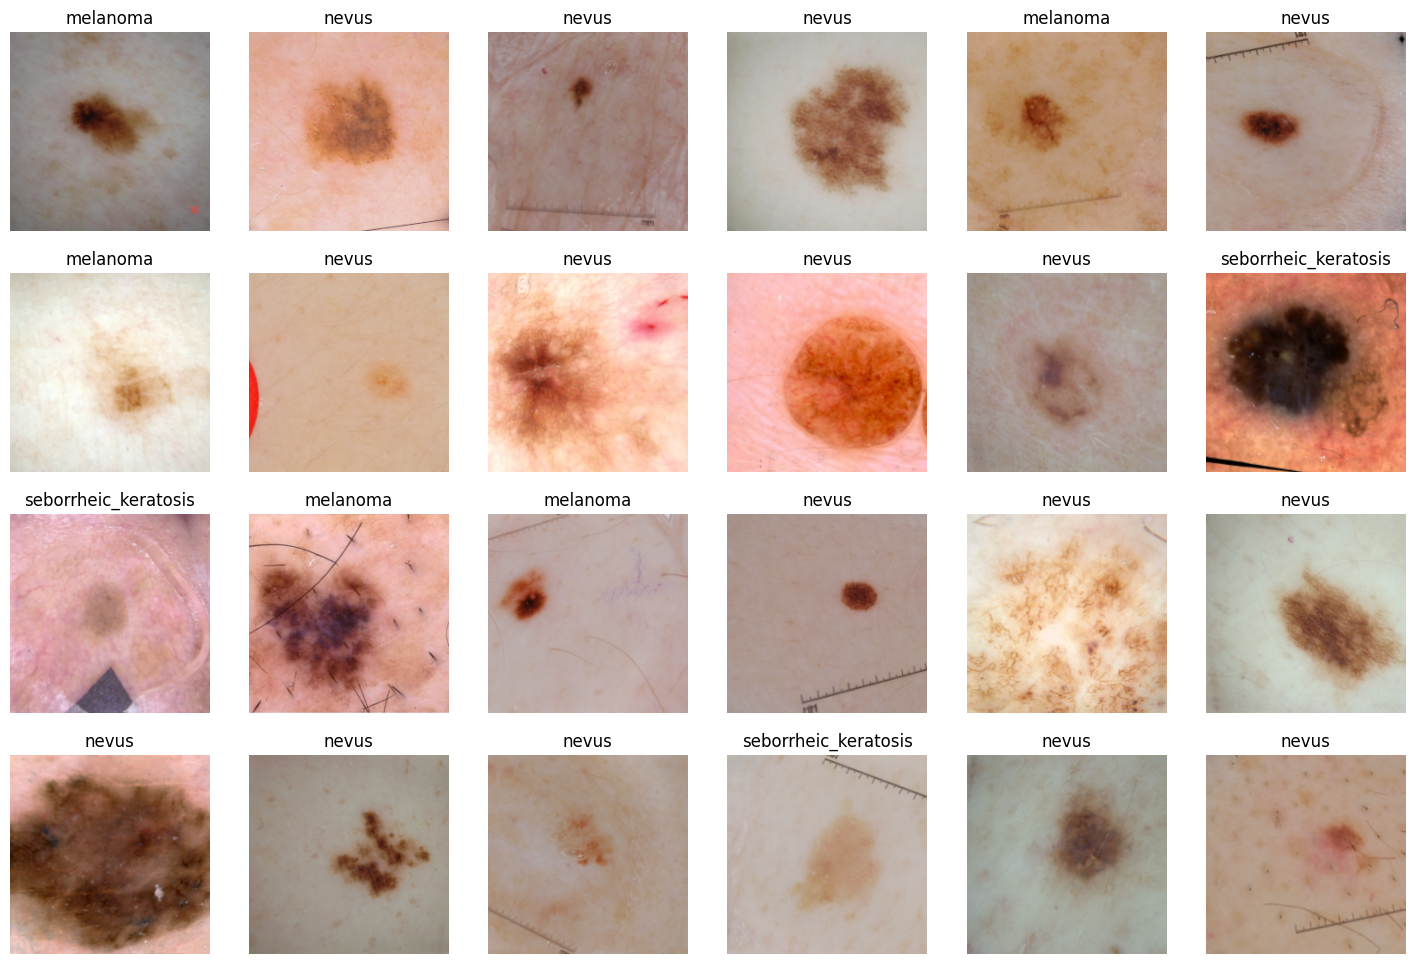

In [ ]:
dtblk = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='train', valid_name='valid'),
    get_y=parent_label,
    item_tfms=Resize(224),
    batch_tfms=[
        *aug_transforms(do_flip=True, max_rotate=10, max_lighting=0.2),
        Normalize.from_stats(*imagenet_stats)
    ]
)

dls=dtblk.dataloaders(path,bs=128)

dls.show_batch(max_n=24)